### Simulating a single electrode for a single participant
Simulating electrode Cz for a single participant when the signal is made up of:
- Aperiodic noise only
- Aperiodic and periodic noise

#### Imports

In [1]:
# Imports required for functionality 
import numpy as np

from dissertation_simulations.params import setup_Cz_simulation_ap
from dissertation_simulations.params import setup_Cz_simulation_full
from dissertation_simulations.params import welch_params
from dissertation_simulations.params import spectral_model_params
from dissertation_simulations.params import freq_range

from neurodsp.sim import sim_oscillation, sim_combined, sim_powerlaw
from neurodsp.plts import plot_time_series
from neurodsp.spectral import compute_spectrum_welch

from specparam import SpectralModel
from specparam.plts import plot_spectra

#### Simulate EEG-like signal for electrode Cz (aperiodic noise only)

The following code achieves the following:
1. Creates a Cz electrode signal that simulates the aperiodic noise only
2. Plots a time series of this signal
3. Computes and plots the power spectra of this signal
4. Fits the spectral model of this signal 

##### Data Simulation setup for Cz signal (aperiodic)

In [2]:
params, times = setup_Cz_simulation_ap() # Params dict that contains simulation setting for Cz signal and "times" for creating time series

n_seconds = params["n_seconds"]
fs = params["s_rate"]
exponent = params["exponent"]
high_pass_filter = params["high_pass_filter"]

##### Simulating aperiodic Cz signal 
The aperiodic simulated signal is created using `sim_powerlaw`, with the following parameters:
1. `n_seconds` - length of data segment
2. `fs` - sampling rate in Hz
3. `exponent` - the steepness of the 1/f-like decay
4. `f_range` - a high-pass filter is utilised to filter out frequencies below this value 

In [3]:
# Simulating aperiodic Cz signal 
cz_signal_ap = sim_powerlaw (n_seconds, fs, exponent = exponent, f_range = [high_pass_filter, None])

##### Plotting the time series of the aperiodic Cz signal 
The simulated signal is then plotted as a time series using the `plot_time_series` function. Two parameters are required for this to run: 
1. `times` - taken from the `setup_Cz_simulation_ap` dict, this generates a time vector for signal processing
2. `cz_signal_ap` - the simulated signal

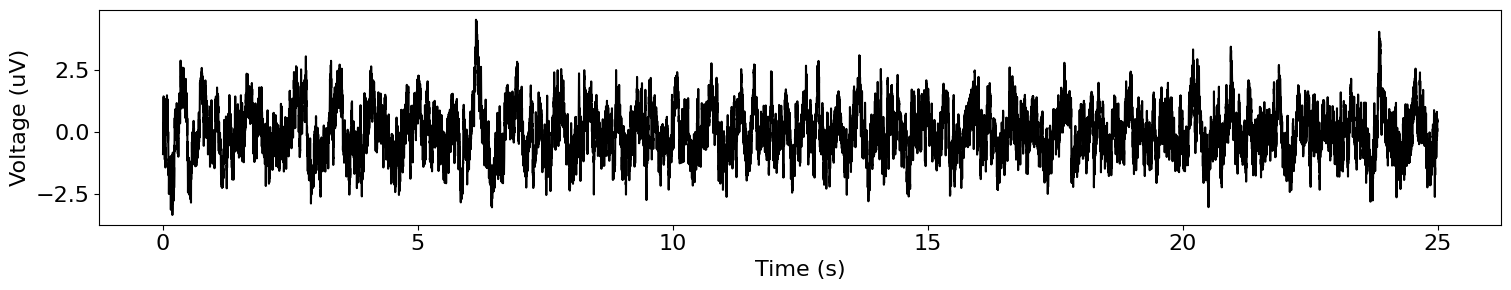

In [4]:
# Plot time series of aperiod Cz signal 
plot_time_series(times, cz_signal_ap)

##### Compute and plot the Power Spectral Density (PSD)
The PSD is computed via the function `compute_spectrum_welch` with the following parameters:
1. `cz_signal_ap` - the simulated signal
2. `fs` - the sampling rate
3. `welch_params` contains the following:
    1. `nperseg` - represents the number of samples per segment. Setting this to the sampling rate means that each segment is 1 second long. This should result in a smoother spectrum
    2. `noverlap` - represents the number of samples that overlap between consecutive segments. Setting this to `fs//2` means that there is a 50% overlap.

The PSD is plotted using `plot_spectra`, which plots the PSD in the frequency domain.

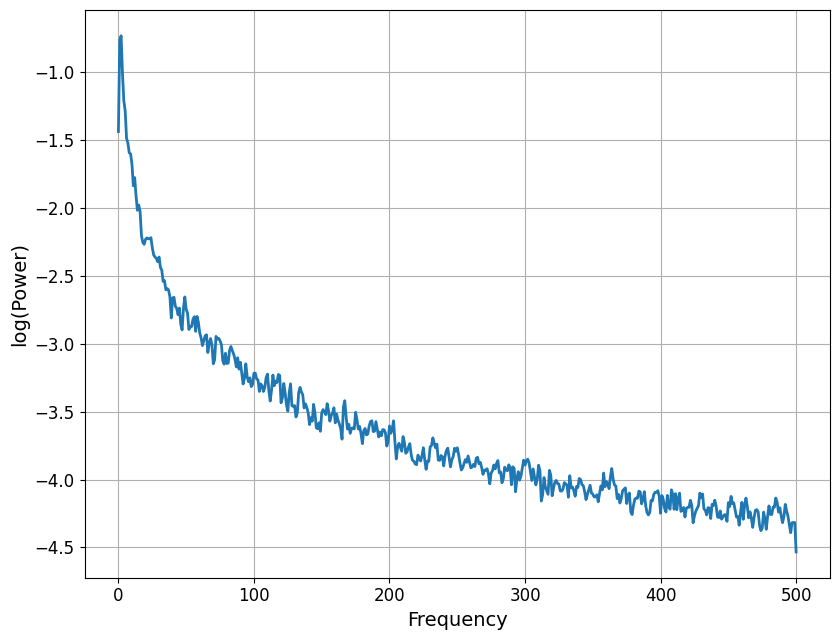

In [5]:
# Plot the simulated data, in the frequency domain
freqs, powers = compute_spectrum_welch(cz_signal_ap, fs, **welch_params)
plot_spectra(freqs, powers, log_powers=True)

##### Plotting the Spectral Model 
The `SpectralModel` is initialised with the following parameters:
1. `spectral_model_params` which contains:
    1. `min_peak_height` - minimum height threshold that a peak must reach for peak detection
    2. `verbose` - switches off warnings for the model

`freq_range` specifies the frequencies at which the model should be plotted between

`.fit` and `.plot` fit and plot the Spectral Model in turn

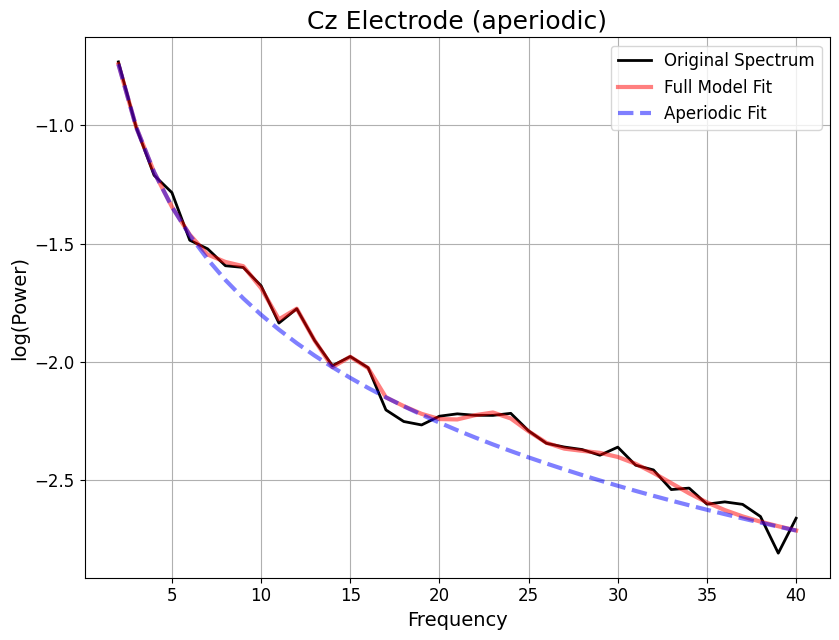

In [6]:
# Initialise Spectral Model
fm_cz = SpectralModel(**spectral_model_params)

# Set frequency range
freq_range = freq_range

# Fitting, plotting and reporting spectral models for each signal
fm_cz.fit(freqs, powers, freq_range)
fm_cz.plot(title = "Cz Electrode (aperiodic)")

#### Simulate EEG-like signal for electrode Cz (aperiodic and periodic)

The following code achieves the following:
1. Creates a Cz electrode signal that simulates the aperiodic and periodic noise
2. Plots a time series of this signal
3. Computes and plots the power spectra of this signal
4. Fits the spectral model of this signal 

##### Data Simulation setup for Cz signal (aperiodic and periodic)

In [7]:
params, times = setup_Cz_simulation_full() # Params dict that contains simulation setting for Cz signal and "times" for creating time series

n_seconds = params["n_seconds"]
fs = params["s_rate"]
exponent = params["exponent"]
high_pass_filter = params["high_pass_filter"]
freq = params ["oscillation"]

##### Simulating Cz signal 
The simulated signal is created using a combination of `sim_powerlaw` and `sim_oscillation`, which are assigned to the variable `components`. 

`sim_powerlaw` contains the following parameters:
1. `exponent` - the steepness of the 1/f-like decay
2. `f_range` - a high-pass filter is utilised to filter out frequencies below this value

`sim_oscillation` contains the following parameter:
1. `freq` - the frequency of the periodic oscillation in Hz

These are combined using the `sim_combined` function with the additional parameters of:
1. `n_seconds` - length of data segment
2. `fs` - sampling rate in Hz
3. `components` - the signals that are being combined

In [8]:
components = {
    'sim_powerlaw': {'exponent': exponent, 'f_range': [high_pass_filter, None]},
    'sim_oscillation': {'freq': freq}
}

cz_signal_full = sim_combined(n_seconds, fs, components=components)                

##### Plotting the time series of the Cz signal 
The simulated signal is then plotted as a time series using the `plot_time_series` function. Two parameters are required for this to run: 
1. `times` - taken from the `setup_Cz_simulation_full` dict, this generates a time vector for signal processing
2. `cz_signal_full` - the simulated signal

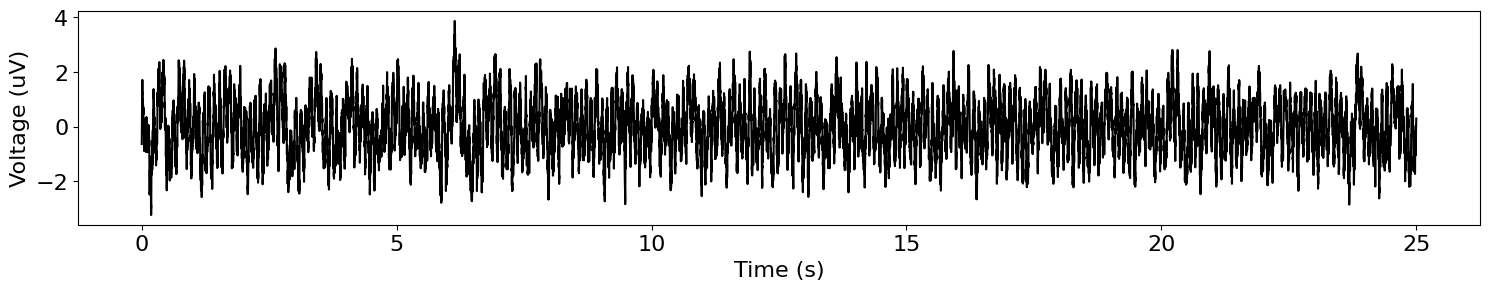

In [9]:
# Plot time series
plot_time_series(times, cz_signal_full)

##### Compute and plot the Power Spectral Density (PSD)
The PSD is computed via the function `compute_spectrum_welch` with the following parameters:
1. `cz_signal_full` - the simulated signal
2. `fs` - the sampling rate
3. `welch_params` contains the following:
    1. `nperseg` - represents the number of samples per segment. Setting this to the sampling rate means that each segment is 1 second long. This should result in a smoother spectrum
    2. `noverlap` - represents the number of samples that overlap between consecutive segments. Setting this to `fs//2` means that there is a 50% overlap.

The PSD is plotted using `plot_spectra`, which plots the PSD in the frequency domain.

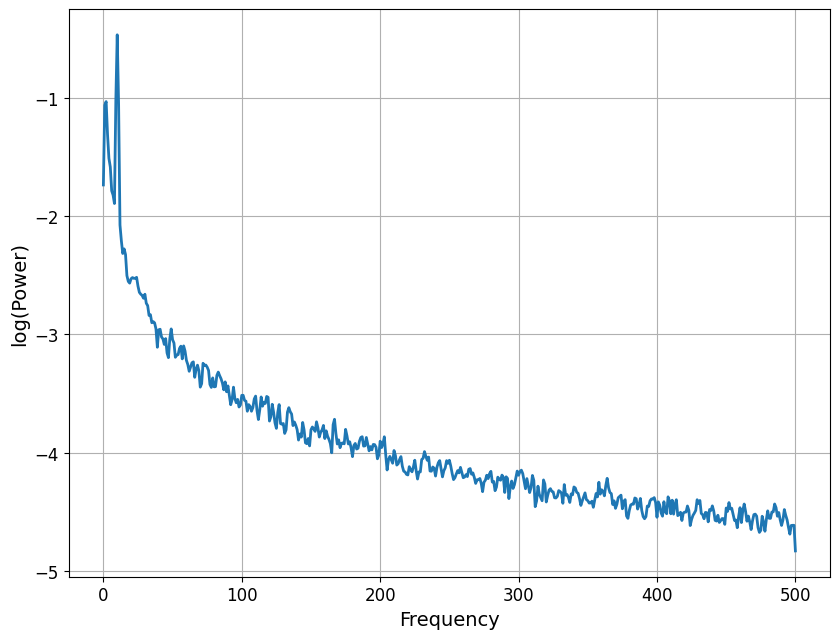

In [10]:
# Plot the simulated data, in the frequency domain
freqs, powers = compute_spectrum_welch(cz_signal_full, fs, **welch_params)
plot_spectra(freqs, powers, log_powers=True)

##### Plotting the Spectral Model 
The `SpectralModel` is initialised with the following parameters:
1. `spectral_model_params` which contains:
    1. `min_peak_height` - minimum height threshold that a peak must reach for peak detection
    2. `verbose` - switches off warnings for the model

`freq_range` specifies the frequencies at which the model should be plotted between

`.fit` and `.plot` fit and plot the Spectral Model in turn

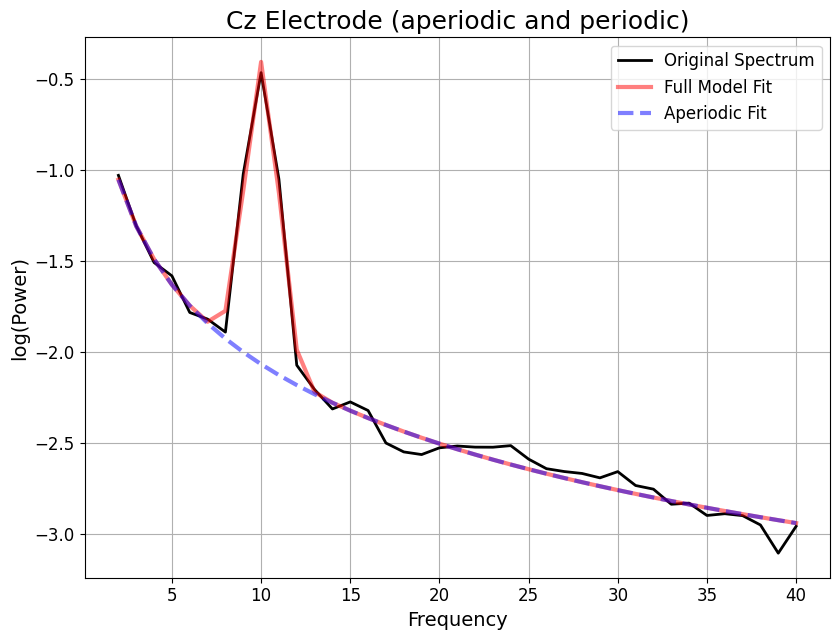

In [11]:
# Initialise Spectral Model
fm_cz = SpectralModel(**spectral_model_params)

# Set frequency range
freq_range = freq_range

# Fitting, plotting and reporting spectral models for each signal
fm_cz.fit(freqs, powers, freq_range)
fm_cz.plot(title = "Cz Electrode (aperiodic and periodic)")